In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:


df = pd.read_csv("dirty_financial_transactions.csv")

# Display first 5 rows
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed


In [9]:


print("Number of Rows   :", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows   : 100000
Number of Columns: 8


In [10]:


print("Dataset Columns:\n")

for col in df.columns:
    print(col)

Dataset Columns:

Transaction_ID
Transaction_Date
Customer_ID
Product_Name
Quantity
Price
Payment_Method
Transaction_Status


In [15]:


df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      94982 non-null   str    
 1   Transaction_Date    95120 non-null   str    
 2   Customer_ID         95122 non-null   str    
 3   Product_Name        100000 non-null  str    
 4   Quantity            94981 non-null   float64
 5   Price               66503 non-null   str    
 6   Payment_Method      100000 non-null  str    
 7   Transaction_Status  83321 non-null   str    
dtypes: float64(1), str(7)
memory usage: 6.1 MB


In [16]:


numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()
datetime_cols = df.select_dtypes(include="datetime").columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\nDate/Time Columns:")
print(datetime_cols)

Numerical Columns:
['Quantity']

Categorical Columns:
['Transaction_ID', 'Transaction_Date', 'Customer_ID', 'Product_Name', 'Price', 'Payment_Method', 'Transaction_Status']

Date/Time Columns:
[]


/var/folders/4z/gn6k3wz57v17g3_1zpq2rvzm0000gn/T/ipykernel_2899/759513354.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


In [17]:

identifier_cols = [col for col in df.columns if "id" in col.lower()]

print("Identifier Columns:")
print(identifier_cols)

Identifier Columns:
['Transaction_ID', 'Customer_ID']


In [19]:


df.sample(10, random_state=42)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
75721,T75722,2022-07-21,C3456,Laptop,-9.0,422.54062324124203,PayPal,Completed
80184,T80185,2025-02-30,C080,Laptop,5.0,-773.4526301779505,credit card,completed
19864,T19865,2023-13-01,C1106,Coffee Machine,5.0,NaN,pay pal,NaN
76699,T76700,2025-02-30,C3862,Coffee Machine,6.0,NaN,Cash,Failed
92991,T92992,2025-02-30,C321,Tablet,-7.0,174.53223890569643,Credit Card,completed
76434,T76435,2021-09-29,C901,Laptop,486.0,279.0015330057047,PayPal,complete
84004,T84005,2025-02-30,C080,Headphones,-8.0,NaN,Cash,NaN
80917,T80918,2023-13-01,C4989,Coffee Machine,681.0,-164.93652904726594,Cash,Completed
60767,T60768,2020-08-30,C2386,Coffee Machine,2.0,NaN,creditcard,Completed
50074,T50075,2023-13-01,C3015,Tablet,6.0,NaN,Credit Card,Completed


In [20]:


df.tail()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
99995,NaN,2021-10-06,C1743,Headphones,-8.0,240.0032380562687,PayPal,complete
99996,T99997,2024-08-25,C4830,Smartphone,NaN,503.82951729633896,credit card,Completed
99997,T99998,2023-13-01,C280,Laptop,-10.0,NaN,PayPal,completed
99998,T99999,2020-07-12,C4059,Headphones,10.0,NaN,PayPal,Completed
99999,T100000,2023-10-04,C1805,Tablet,2.0,89.37402345793535,PayPal,Failed


In [21]:


df.describe(include="all")

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
count,94982,95120,95122,100000,94981.000000,66503,100000,83321
unique,94040,1861,5000,46,NaN,65757,7,5
top,T22566,2023-13-01,C2023,Tablet,NaN,$103.82,Credit Card,Failed
freq,3,31834,37,18444,NaN,3,14433,16795
mean,NaN,NaN,NaN,NaN,183.883914,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,299.292365,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-10.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,-3.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,327.000000,NaN,NaN,NaN


In [24]:


missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary

,Missing Values,Missing Percentage
Transaction_ID,5018,5.02
Transaction_Date,4880,4.88
Customer_ID,4878,4.88
Quantity,5019,5.02
Price,33497,33.50
Transaction_Status,16679,16.68


In [25]:


duplicate_rows = df.duplicated().sum()
print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 994


In [26]:


duplicate_records = df[df.duplicated()]

duplicate_records

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
3544,T1579,NaN,C2854,Headphones,4.0,978.806380519704,credit card,completed
4816,T4817,2023-13-01,C756,Laptop,170.0,-461.44380335792755,Cash,NaN
5455,T5456,2022-11-01,C1548,Tablet,530.0,-706.4750815495283,PayPal,Pending
5938,T5939,2023-04-14,C2656,Laptop,6.0,NaN,Cash,complete
8125,T8126,2021-05-25,C2396,Smartphone,-4.0,335.9920520635594,PayPal,completed
...,...,...,...,...,...,...,...,...
99674,T47093,2023-13-01,C4823,Tablet,-6.0,-522.4003199263182,creditcard,Completed
99786,T15545,2023-13-01,C2823,Laptop,3.0,NaN,pay pal,completed
99866,T6571,2023-13-01,C4483,Smartphone,2.0,421.99494928905284,PayPal,completed
99984,NaN,2022-01-26,C4753,Laptop,480.0,-558.7481358840021,Cash,completed


In [28]:

duplicate_ids = df[df["Transaction_ID"].duplicated(keep=False)]

duplicate_ids

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
6,NaN,2025-02-30,C1313,Laptop,10.0,NaN,credit card,Completed
26,T73466,2025-02-30,C2702,Coffee Machine,-5.0,555.6133483579025,creditcard,complete
90,NaN,2023-05-16,C308,Coffee Machine,824.0,577.5607699389858,creditcard,Failed
105,NaN,2025-02-30,C4261,Laptop,670.0,-197.03277785431612,pay pal,Failed
124,NaN,2021-12-02,C086,Coffee Machine,667.0,$-681.87,PayPal,Pending
...,...,...,...,...,...,...,...,...
99955,NaN,2020-07-23,C4753,Coffee Machine,9.0,876.2470391045515,PayPal,Pending
99973,NaN,2023-13-01,C918,Coffee Machine,702.0,NaN,credit card,Pending
99984,NaN,2022-01-26,C4753,Laptop,480.0,-558.7481358840021,Cash,completed
99995,NaN,2021-10-06,C1743,Headphones,-8.0,240.0032380562687,PayPal,complete


In [29]:


print("Duplicate Transaction IDs:", df["Transaction_ID"].duplicated().sum())

Duplicate Transaction IDs: 5959


In [30]:


df.dtypes

Transaction_ID            str
Transaction_Date          str
Customer_ID               str
Product_Name              str
Quantity              float64
Price                     str
Payment_Method            str
Transaction_Status        str
dtype: object

In [31]:


object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    numeric_count = pd.to_numeric(df[col], errors="coerce").notnull().sum()
    
    if numeric_count > 0:
        print(f"{col}: {numeric_count} values can be converted to numeric")

Price: 59863 values can be converted to numeric


/var/folders/4z/gn6k3wz57v17g3_1zpq2rvzm0000gn/T/ipykernel_2899/4005036580.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


In [32]:


for col in object_cols:
    date_count = pd.to_datetime(df[col], errors="coerce").notnull().sum()
    
    if date_count > 0:
        print(f"{col}: {date_count} values can be converted to datetime")

/var/folders/4z/gn6k3wz57v17g3_1zpq2rvzm0000gn/T/ipykernel_2899/2241375275.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


Transaction_ID: 9428 values can be converted to datetime
Transaction_Date: 31739 values can be converted to datetime


/var/folders/4z/gn6k3wz57v17g3_1zpq2rvzm0000gn/T/ipykernel_2899/2241375275.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
/var/folders/4z/gn6k3wz57v17g3_1zpq2rvzm0000gn/T/ipykernel_2899/2241375275.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
/var/folders/4z/gn6k3wz57v17g3_1zpq2rvzm0000gn/T/ipykernel_2899/2241375275.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
/var/folders/4z/gn6k3wz57v17g3_1zpq2rvzm0000gn/T/ipykernel_2899/2241375275.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure pars

In [33]:
import pandas as pd


unique_values_df = pd.DataFrame({
    "Categorical Column": categorical_cols,
    "Unique Values": [df[col].dropna().unique().tolist() for col in categorical_cols],
    "Unique Count": [df[col].nunique(dropna=True) for col in categorical_cols]
})

display(unique_values_df)

,Categorical Column,Unique Values,Unique Count
0,Transaction_ID,"[T0001, T0002, T0003, T0004, T0005, T0006, T00...",94040
1,Transaction_Date,"[2024-08-02, 2020-02-10, 2025-02-30, 2020-08-1...",1861
2,Customer_ID,"[C2205, C3156, C2919, C3009, C3488, C4241, C13...",5000
3,Product_Name,"[Headphones, Coffee , Tablet, Tab, Coffee Mach...",46
4,Price,"[$420.21, -445.34202525395585, 810.99301239464...",65757
5,Payment_Method,"[pay pal, creditcard, credit card, PayPal, Cas...",7
6,Transaction_Status,"[Pending, completed, Completed, complete, Failed]",5


In [34]:

capitalization_df = pd.concat(
    [
        df[col]
        .value_counts(dropna=False)
        .rename_axis("Value")
        .reset_index(name="Count")
        .assign(Column=col)
        for col in categorical_cols
    ],
    ignore_index=True
)


capitalization_df = capitalization_df[
    ["Column", "Value", "Count"]
]

display(capitalization_df)

,Column,Value,Count
0,Transaction_ID,NaN,5018
1,Transaction_ID,T22566,3
2,Transaction_ID,T1258,3
3,Transaction_ID,T1685,3
4,Transaction_ID,T57553,3
...,...,...,...
166716,Transaction_Status,complete,16717
166717,Transaction_Status,completed,16687
166718,Transaction_Status,NaN,16679
166719,Transaction_Status,Pending,16595


In [35]:


space_summary = pd.DataFrame({
    "Column": categorical_cols,
    "Values with Extra Spaces": [
        (df[col].astype(str).str.strip() != df[col].astype(str)).sum()
        for col in categorical_cols
    ]
})

space_summary

,Column,Values with Extra Spaces
0,Transaction_ID,5018
1,Transaction_Date,4880
2,Customer_ID,4878
3,Product_Name,149
4,Price,33497
5,Payment_Method,14262
6,Transaction_Status,16679


In [36]:

spelling_df = pd.concat(
    [
        df[col]
        .value_counts(dropna=False)
        .rename_axis("Value")
        .reset_index(name="Count")
        .assign(Column=col)
        for col in categorical_cols
    ],
    ignore_index=True
)
spelling_df = spelling_df[
    ["Column", "Value", "Count"]
]

display(spelling_df)

,Column,Value,Count
0,Transaction_ID,NaN,5018
1,Transaction_ID,T22566,3
2,Transaction_ID,T1258,3
3,Transaction_ID,T1685,3
4,Transaction_ID,T57553,3
...,...,...,...
166716,Transaction_Status,complete,16717
166717,Transaction_Status,completed,16687
166718,Transaction_Status,NaN,16679
166719,Transaction_Status,Pending,16595


In [26]:

space_df = pd.concat(
    [
        pd.DataFrame({
            "Column": [col] * len(space_values.unique()),
            "Value with Spaces": space_values.unique()
        })
        for col in categorical_cols
        for space_values in [
            df.loc[
                df[col].astype(str).str.strip() != df[col].astype(str),
                col
            ]
        ]
        if not space_values.empty
    ],
    ignore_index=True
)

display(space_df)

,Column,Value with Spaces
0,Transaction_ID,NaN
1,Transaction_Date,NaN
2,Customer_ID,NaN
3,Product_Name,Coffee
4,Price,NaN
5,Payment_Method,PayPal
6,Transaction_Status,NaN


In [37]:


for col in categorical_cols:
    original = df[col].nunique(dropna=False)
    trimmed = df[col].astype(str).str.strip().nunique(dropna=False)

    if original != trimmed:
        print(f"{col}:")
        print(f"Unique values before trimming : {original}")
        print(f"Unique values after trimming  : {trimmed}\n")

Product_Name:
Unique values before trimming : 46
Unique values after trimming  : 45

Payment_Method:
Unique values before trimming : 7
Unique values after trimming  : 6



In [38]:


numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print(numerical_cols)

Index(['Quantity'], dtype='str')


In [39]:

for col in numerical_cols:
    negative_values = df[df[col] < 0]

    if not negative_values.empty:
        print(f"\n----- {col} -----")
        print(negative_values[[col]])


----- Quantity -----
       Quantity
0          -5.0
2          -4.0
3          -7.0
4         -10.0
9          -1.0
...         ...
99983      -1.0
99985      -1.0
99987      -6.0
99995      -8.0
99997     -10.0

[31619 rows x 1 columns]


In [40]:


for col in numerical_cols:
    zero_count = (df[col] == 0).sum()

    if zero_count > 0:
        print(f"{col}: {zero_count} zero value(s)")

In [41]:

df[numerical_cols].describe()

,Quantity
count,94981.000000
mean,183.883914
std,299.292365
min,-10.000000
25%,-3.000000
50%,6.000000
75%,327.000000
max,1000.000000


In [42]:


for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print(f"{col}: {len(outliers)} outlier(s)")

Quantity: 6273 outlier(s)


In [43]:


for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    if not outliers.empty:
        print(f"\n----- {col} -----")
        display(outliers)


----- Quantity -----


,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
20,T0021,2025-02-30,C1137,Coffee Machine,856.0,-488.8626491104135,Credit Card,Failed
40,T0041,2023-10-20,C1693,Laptop,865.0,NaN,credit card,Completed
45,T0046,2025-02-30,C2797,Coffee Machine,825.0,-788.7705027101282,PayPal,Completed
51,T0052,2022-12-20,C4029,Headphones,839.0,-756.3340765354607,PayPal,Pending
54,T0055,2024-04-17,C2474,Coffee Machine,867.0,130.23186429200612,creditcard,Pending
...,...,...,...,...,...,...,...,...
99876,T99877,2024-07-16,C3496,Headphones,855.0,NaN,Cash,NaN
99897,T99898,2021-06-21,C2043,Coffee Machine,962.0,NaN,PayPal,Completed
99904,T99905,NaN,C667,Laptop,856.0,NaN,PayPal,Completed
99928,T99929,2023-13-01,C2897,Laptop,960.0,NaN,pay pal,NaN


In [44]:

outlier_summary = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    count = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()

    outlier_summary.append([col, count])

outlier_summary = pd.DataFrame(outlier_summary, columns=["Column", "Outliers"])

outlier_summary

,Column,Outliers
0,Quantity,6273


In [46]:


date_cols = [col for col in df.columns if "date" in col.lower()]

print("Date Columns:")
print(date_cols)

Date Columns:
['Transaction_Date']


In [47]:
# Check for Invalid Date Formats

for col in date_cols:
    invalid_dates = pd.to_datetime(df[col], errors="coerce").isna().sum()

    print(f"{col}: {invalid_dates} invalid date(s)")

Transaction_Date: 68261 invalid date(s)


In [48]:


today = pd.Timestamp.today()

for col in date_cols:
    dates = pd.to_datetime(df[col], errors="coerce")

    future_dates = df[dates > today]

    if not future_dates.empty:
        print(f"\n----- {col} -----")
        display(future_dates)

In [49]:

for col in date_cols:
    missing_dates = df[df[col].isnull()]

    if not missing_dates.empty:
        print(f"\n----- {col} -----")
        display(missing_dates)


----- Transaction_Date -----


,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
8,T0009,NaN,C3387,Tablet,10.0,461.70198437439694,PayPal,NaN
43,T0044,NaN,C246,Smar,-10.0,NaN,Cash,Completed
58,T0059,NaN,C2809,Tablet,4.0,-329.6249100867068,credit card,NaN
61,T0062,NaN,C3832,Laptop,2.0,NaN,PayPal,Pending
88,T0089,NaN,C4555,Headphones,709.0,NaN,PayPal,completed
...,...,...,...,...,...,...,...,...
99904,T99905,NaN,C667,Laptop,856.0,NaN,PayPal,Completed
99915,T99916,NaN,C4792,Smartphone,-1.0,-141.5282186377617,pay pal,Failed
99918,T99919,NaN,C2577,Smartphone,-1.0,NaN,pay pal,Failed
99926,T99927,NaN,C1280,Headphones,9.0,NaN,pay pal,NaN


In [50]:

id_cols = [col for col in df.columns if "id" in col.lower()]

print("Identifier Columns:")
print(id_cols)

Identifier Columns:
['Transaction_ID', 'Customer_ID']


In [51]:

for col in id_cols:
    missing = df[col].isnull().sum()

    print(f"{col}: {missing} missing value(s)")

Transaction_ID: 5018 missing value(s)
Customer_ID: 4878 missing value(s)


In [52]:

for col in id_cols:
    missing_records = df[df[col].isnull()]

    if not missing_records.empty:
        print(f"\n----- {col} -----")
        display(missing_records)


----- Transaction_ID -----


,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
6,NaN,2025-02-30,C1313,Laptop,10.0,NaN,credit card,Completed
90,NaN,2023-05-16,C308,Coffee Machine,824.0,577.5607699389858,creditcard,Failed
105,NaN,2025-02-30,C4261,Laptop,670.0,-197.03277785431612,pay pal,Failed
124,NaN,2021-12-02,C086,Coffee Machine,667.0,$-681.87,PayPal,Pending
140,NaN,2023-13-01,C869,Headphones,564.0,499.8782079245941,creditcard,Failed
...,...,...,...,...,...,...,...,...
99952,NaN,2021-02-19,C2748,Laptop,1.0,800.9031543971622,credit card,Pending
99955,NaN,2020-07-23,C4753,Coffee Machine,9.0,876.2470391045515,PayPal,Pending
99973,NaN,2023-13-01,C918,Coffee Machine,702.0,NaN,credit card,Pending
99984,NaN,2022-01-26,C4753,Laptop,480.0,-558.7481358840021,Cash,completed



----- Customer_ID -----


,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
31,T0032,2023-10-05,NaN,Laptop,-7.0,NaN,Credit Card,Completed
49,T0050,2021-04-23,NaN,Tablet,-6.0,$969.72,PayPal,Completed
59,T0060,2025-02-30,NaN,Headphones,9.0,-774.7400993737688,pay pal,complete
81,T0082,2025-02-30,NaN,Laptop,2.0,-386.6519715886566,PayPal,NaN
119,T0120,2025-02-30,NaN,Coffee Machine,-7.0,159.45851825246467,PayPal,Failed
...,...,...,...,...,...,...,...,...
99860,T99861,2025-02-30,NaN,Tablet,3.0,NaN,Credit Card,Completed
99861,T99862,2025-02-30,NaN,Smartphone,-8.0,160.65144834291772,Cash,NaN
99911,T99912,2023-02-14,NaN,Headphones,-2.0,98.05018719630868,Cash,Failed
99927,T99928,2025-02-30,NaN,Smartphone,-5.0,-951.5353783037484,PayPal,complete


In [53]:
import pandas as pd


frequency_df = pd.concat(
    [
        df[col]
        .value_counts(dropna=False)
        .rename_axis("Value")
        .reset_index(name="Frequency")
        .assign(Column=col)
        for col in categorical_cols
    ],
    ignore_index=True
)


frequency_df = frequency_df[
    ["Column", "Value", "Frequency"]
]

display(frequency_df)

,Column,Value,Frequency
0,Transaction_ID,NaN,5018
1,Transaction_ID,T22566,3
2,Transaction_ID,T1258,3
3,Transaction_ID,T1685,3
4,Transaction_ID,T57553,3
...,...,...,...
166716,Transaction_Status,complete,16717
166717,Transaction_Status,completed,16687
166718,Transaction_Status,NaN,16679
166719,Transaction_Status,Pending,16595


In [54]:

bivariate_summary = []

for cat_col in categorical_cols:
    for num_col in numerical_cols:
        summary = (
            df.groupby(cat_col)[num_col]
              .agg(["count", "sum", "mean", "min", "max"])
              .reset_index()
        )

        summary.insert(0, "Categorical Feature", cat_col)
        summary.insert(1, "Numerical Feature", num_col)

        bivariate_summary.append(summary)

bivariate_summary = pd.concat(bivariate_summary, ignore_index=True)

bivariate_summary

,Categorical Feature,Numerical Feature,Transaction_ID,count,sum,mean,min,max,Transaction_Date,Customer_ID,Product_Name,Price,Payment_Method,Transaction_Status
0,Transaction_ID,Quantity,T0001,1,-5.0,-5.000000,-5.0,-5.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Transaction_ID,Quantity,T0002,1,469.0,469.000000,469.0,469.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Transaction_ID,Quantity,T0003,1,-4.0,-4.000000,-4.0,-4.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Transaction_ID,Quantity,T0004,1,-7.0,-7.000000,-7.0,-7.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Transaction_ID,Quantity,T0005,1,-10.0,-10.000000,-10.0,-10.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166711,Transaction_Status,Quantity,NaN,15707,2910760.0,185.316101,-10.0,1000.0,NaN,NaN,NaN,NaN,NaN,Completed
166712,Transaction_Status,Quantity,NaN,15923,2949168.0,185.214344,-10.0,1000.0,NaN,NaN,NaN,NaN,NaN,Failed
166713,Transaction_Status,Quantity,NaN,15789,2876015.0,182.153081,-10.0,1000.0,NaN,NaN,NaN,NaN,NaN,Pending
166714,Transaction_Status,Quantity,NaN,15859,2919665.0,184.101457,-10.0,1000.0,NaN,NaN,NaN,NaN,NaN,complete


In [55]:

multivariate_summary = []

for cat_col1 in categorical_cols:
    for cat_col2 in categorical_cols:

        if cat_col1 != cat_col2:

            for num_col in numerical_cols:

                summary = (
                    df.groupby([cat_col1, cat_col2])[num_col]
                      .agg(["count", "sum", "mean", "min", "max"])
                      .reset_index()
                )

                summary.insert(0, "Feature 1", cat_col1)
                summary.insert(1, "Feature 2", cat_col2)
                summary.insert(2, "Numerical Feature", num_col)

                multivariate_summary.append(summary)

multivariate_summary = pd.concat(multivariate_summary, ignore_index=True)

multivariate_summary

,Feature 1,Feature 2,Numerical Feature,Transaction_ID,Transaction_Date,count,sum,mean,min,max,Customer_ID,Product_Name,Price,Payment_Method,Transaction_Status
0,Transaction_ID,Transaction_Date,Quantity,T0001,2024-08-02,1,-5.0,-5.000000,-5.0,-5.0,NaN,NaN,NaN,NaN,NaN
1,Transaction_ID,Transaction_Date,Quantity,T0002,2020-02-10,1,469.0,469.000000,469.0,469.0,NaN,NaN,NaN,NaN,NaN
2,Transaction_ID,Transaction_Date,Quantity,T0003,2025-02-30,1,-4.0,-4.000000,-4.0,-4.0,NaN,NaN,NaN,NaN,NaN
3,Transaction_ID,Transaction_Date,Quantity,T0004,2020-08-17,1,-7.0,-7.000000,-7.0,-7.0,NaN,NaN,NaN,NaN,NaN
4,Transaction_ID,Transaction_Date,Quantity,T0005,2025-02-30,1,-10.0,-10.000000,-10.0,-10.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963323,Transaction_Status,Payment_Method,Quantity,NaN,NaN,2284,416222.0,182.233800,-10.0,1000.0,NaN,NaN,NaN,PayPal,completed
1963324,Transaction_Status,Payment_Method,Quantity,NaN,NaN,2304,412477.0,179.026476,-10.0,1000.0,NaN,NaN,NaN,PayPal,completed
1963325,Transaction_Status,Payment_Method,Quantity,NaN,NaN,2252,411494.0,182.723801,-10.0,1000.0,NaN,NaN,NaN,credit card,completed
1963326,Transaction_Status,Payment_Method,Quantity,NaN,NaN,2250,409474.0,181.988444,-10.0,999.0,NaN,NaN,NaN,creditcard,completed


In [56]:

correlation_matrix = df[numerical_cols].corr()

correlation_summary = (
    correlation_matrix
    .stack()
    .reset_index()
)

correlation_summary.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation"
]


correlation_summary = correlation_summary[
    correlation_summary["Variable 1"] != correlation_summary["Variable 2"]
]

correlation_summary["Pair"] = correlation_summary.apply(
    lambda x: tuple(sorted([x["Variable 1"], x["Variable 2"]])),
    axis=1
)

correlation_summary = correlation_summary.drop_duplicates(subset="Pair")
correlation_summary = correlation_summary.drop(columns="Pair")

correlation_summary["Relationship"] = correlation_summary["Correlation"].apply(
    lambda x: "Positive Correlation" if x > 0
    else "Negative Correlation" if x < 0
    else "No Correlation"
)

correlation_summary

,Variable 1,Variable 2,Correlation,Relationship


In [57]:

revenue_col = numerical_cols[0]   
date_col = date_cols[0] if len(date_cols) > 0 else None

revenue_summary = {
    "Total Revenue": df[revenue_col].sum(),
    "Average Revenue": df[revenue_col].mean(),
    "Highest Revenue": df[revenue_col].max(),
    "Lowest Revenue": df[revenue_col].min()
}

revenue_summary = pd.DataFrame(revenue_summary.items(), columns=["Metric", "Value"])

# Revenue Trend (if a date column exists)
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    revenue_trend = (
        df.groupby(date_col)[revenue_col]
          .sum()
          .reset_index()
          .rename(columns={date_col: "Metric", revenue_col: "Value"})
    )

    revenue_trend["Metric"] = "Revenue on " + revenue_trend["Metric"].astype(str)

    revenue_summary = pd.concat([revenue_summary, revenue_trend], ignore_index=True)

revenue_summary

,Metric,Value
0,Total Revenue,1.746548e+07
1,Average Revenue,1.838839e+02
2,Highest Revenue,1.000000e+03
3,Lowest Revenue,-1.000000e+01
4,Revenue on 2020-01-01,4.127000e+03
...,...,...
1858,Revenue on 2025-01-28,1.571000e+03
1859,Revenue on 2025-01-29,2.254000e+03
1860,Revenue on 2025-01-30,3.963000e+03
1861,Revenue on 2025-01-31,3.714000e+03


In [58]:


payment_col = categorical_cols[0]     
revenue_col = numerical_cols[0]       
status_col = categorical_cols[1]       

payment_summary = (
    df.groupby(payment_col)
      .agg(
          Total_Transactions=(payment_col, "count"),
          Total_Revenue=(revenue_col, "sum"),
          Average_Revenue=(revenue_col, "mean")
      )
      .reset_index()
)

# Successful Transactions
success = (
    df[df[status_col].astype(str).str.lower() == "success"]
    .groupby(payment_col)
    .size()
    .reset_index(name="Successful_Transactions")
)

# Merge Success Counts
payment_summary = payment_summary.merge(
    success,
    on=payment_col,
    how="left"
)

payment_summary["Successful_Transactions"] = (
    payment_summary["Successful_Transactions"].fillna(0).astype(int)
)

# Success Rate
payment_summary["Success_Rate (%)"] = (
    payment_summary["Successful_Transactions"]
    / payment_summary["Total_Transactions"]
    * 100
).round(2)

# Most Common Payment Method
payment_summary["Most_Used"] = ""

max_transactions = payment_summary["Total_Transactions"].max()

payment_summary.loc[
    payment_summary["Total_Transactions"] == max_transactions,
    "Most_Used"
] = "Yes"

payment_summary

,Transaction_ID,Total_Transactions,Total_Revenue,Average_Revenue,Successful_Transactions,Success_Rate (%),Most_Used
0,T0001,1,-5.0,-5.0,0,0.0,
1,T0002,1,469.0,469.0,0,0.0,
2,T0003,1,-4.0,-4.0,0,0.0,
3,T0004,1,-7.0,-7.0,0,0.0,
4,T0005,1,-10.0,-10.0,0,0.0,
...,...,...,...,...,...,...,...
94035,T99994,1,911.0,911.0,0,0.0,
94036,T99995,1,741.0,741.0,0,0.0,
94037,T99997,1,0.0,NaN,0,0.0,
94038,T99998,1,-10.0,-10.0,0,0.0,


In [59]:


status_col = categorical_cols[1]    
revenue_col = numerical_cols[0]    

transaction_summary = (
    df.groupby(status_col)
      .agg(
          Total_Transactions=(status_col, "count"),
          Total_Revenue=(revenue_col, "sum"),
          Average_Revenue=(revenue_col, "mean")
      )
      .reset_index()
)

# Percentage of Total Transactions
transaction_summary["Transaction (%)"] = (
    transaction_summary["Total_Transactions"]
    / transaction_summary["Total_Transactions"].sum()
    * 100
).round(2)

# Transaction Type
transaction_summary["Transaction Type"] = transaction_summary[status_col].replace({
    "Success": "Successful Transactions",
    "Successful": "Successful Transactions",
    "Completed": "Successful Transactions",
    "Failed": "Failed Transactions",
    "Pending": "Pending Transactions",
    "Refund": "Refund Transactions",
    "Refunded": "Refund Transactions"
})

transaction_summary

,Transaction_Date,Total_Transactions,Total_Revenue,Average_Revenue,Transaction (%),Transaction Type
0,2020-01-01,16,4127.0,294.785714,0.05,2020-01-01
1,2020-01-02,18,2872.0,159.555556,0.06,2020-01-02
2,2020-01-03,11,707.0,64.272727,0.03,2020-01-03
3,2020-01-04,14,579.0,44.538462,0.04,2020-01-04
4,2020-01-05,21,3514.0,184.947368,0.07,2020-01-05
...,...,...,...,...,...,...
1854,2025-01-28,20,1571.0,78.550000,0.06,2025-01-28
1855,2025-01-29,17,2254.0,150.266667,0.05,2025-01-29
1856,2025-01-30,20,3963.0,233.117647,0.06,2025-01-30
1857,2025-01-31,24,3714.0,161.478261,0.08,2025-01-31


In [60]:
from plotnine import *

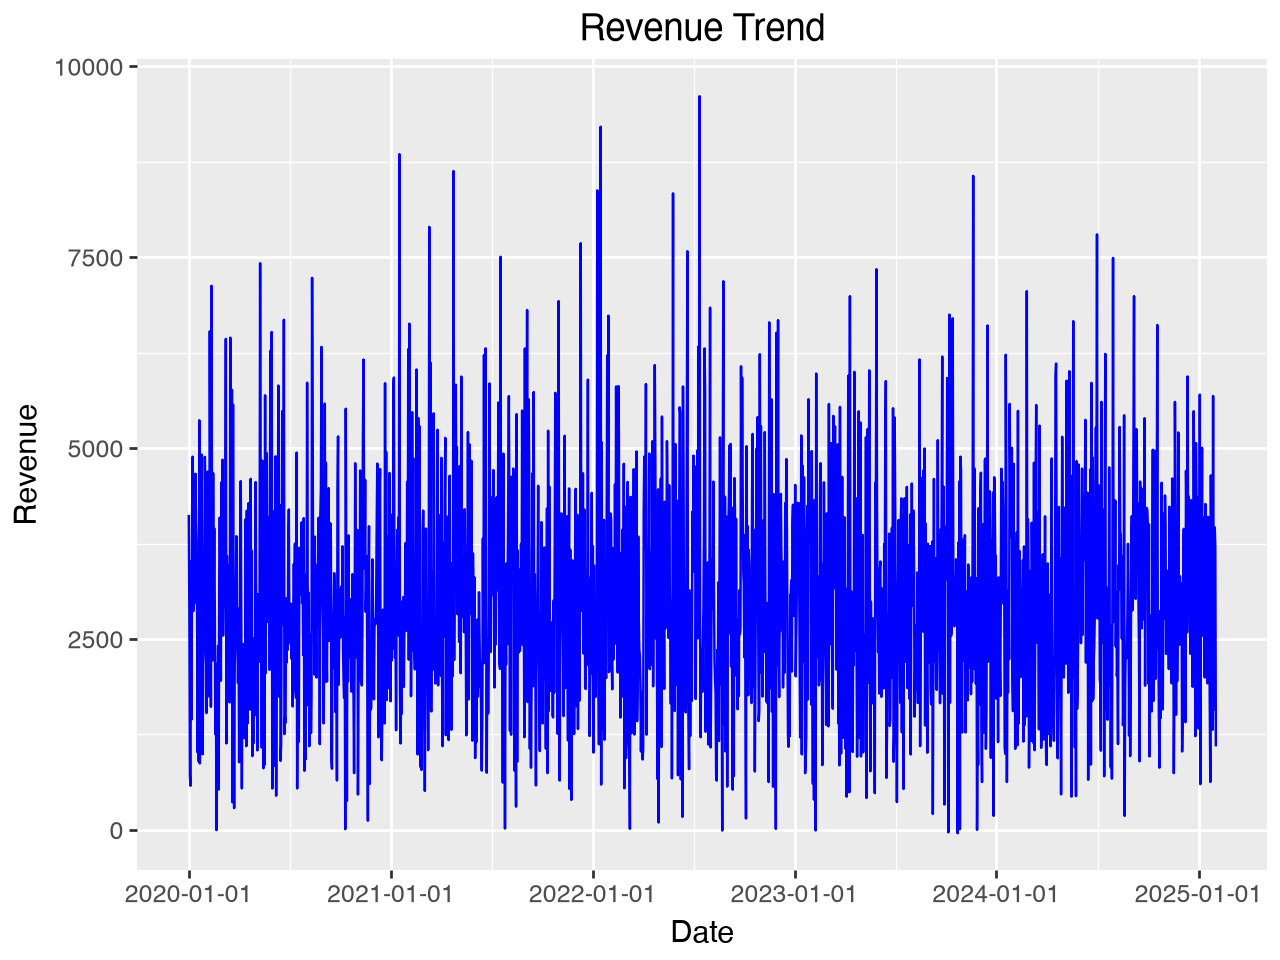

In [61]:
date_col = date_cols[0]
revenue_col = numerical_cols[0]

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

line_data = (
    df.groupby(date_col)[revenue_col]
      .sum()
      .reset_index()
)

ggplot(line_data, aes(x=date_col, y=revenue_col)) + \
    geom_line(color="blue") + \
    labs(
        title="Revenue Trend",
        x="Date",
        y="Revenue"
    )

In [ ]:
revenue_data = (
    df.groupby(categorical_cols[0])[numerical_cols[0]]
      .sum()
      .reset_index()
)

ggplot(revenue_data,
       aes(x=categorical_cols[0], y=numerical_cols[0])) + \
    geom_col(fill="orange") + \
    labs(
        title="Revenue by Category",
        x=categorical_cols[0],
        y="Revenue"
    )

/Users/amento/MachineLearning/.venv/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 5019 rows containing non-finite values.


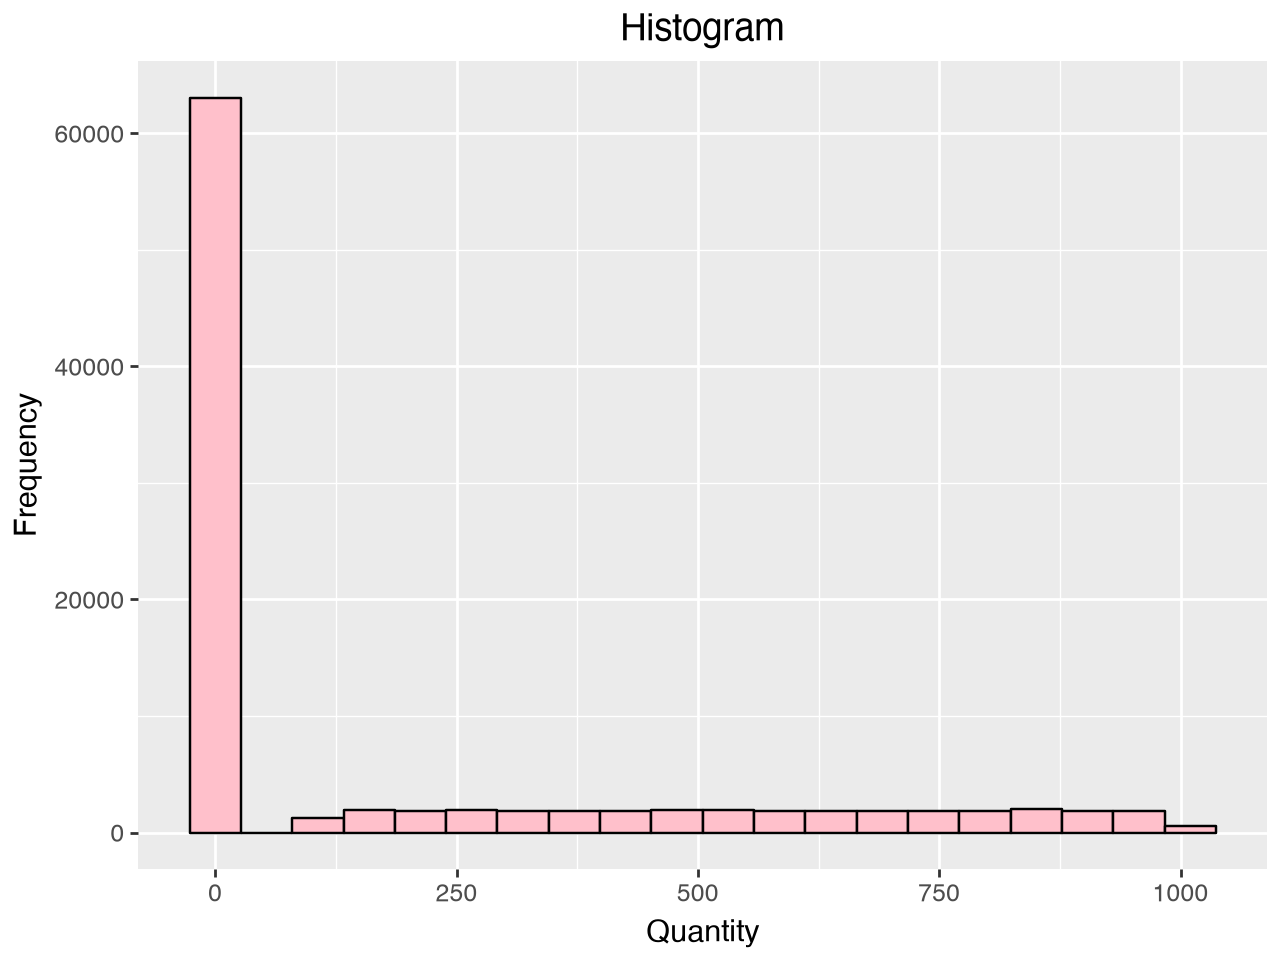

In [63]:
ggplot(df, aes(x=numerical_cols[0])) + \
    geom_histogram(
        bins=20,
        fill="pink",
        color="black"
    ) + \
    labs(
        title="Histogram",
        x=numerical_cols[0],
        y="Frequency"
    )

/Users/amento/MachineLearning/.venv/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 5019 rows containing non-finite values.


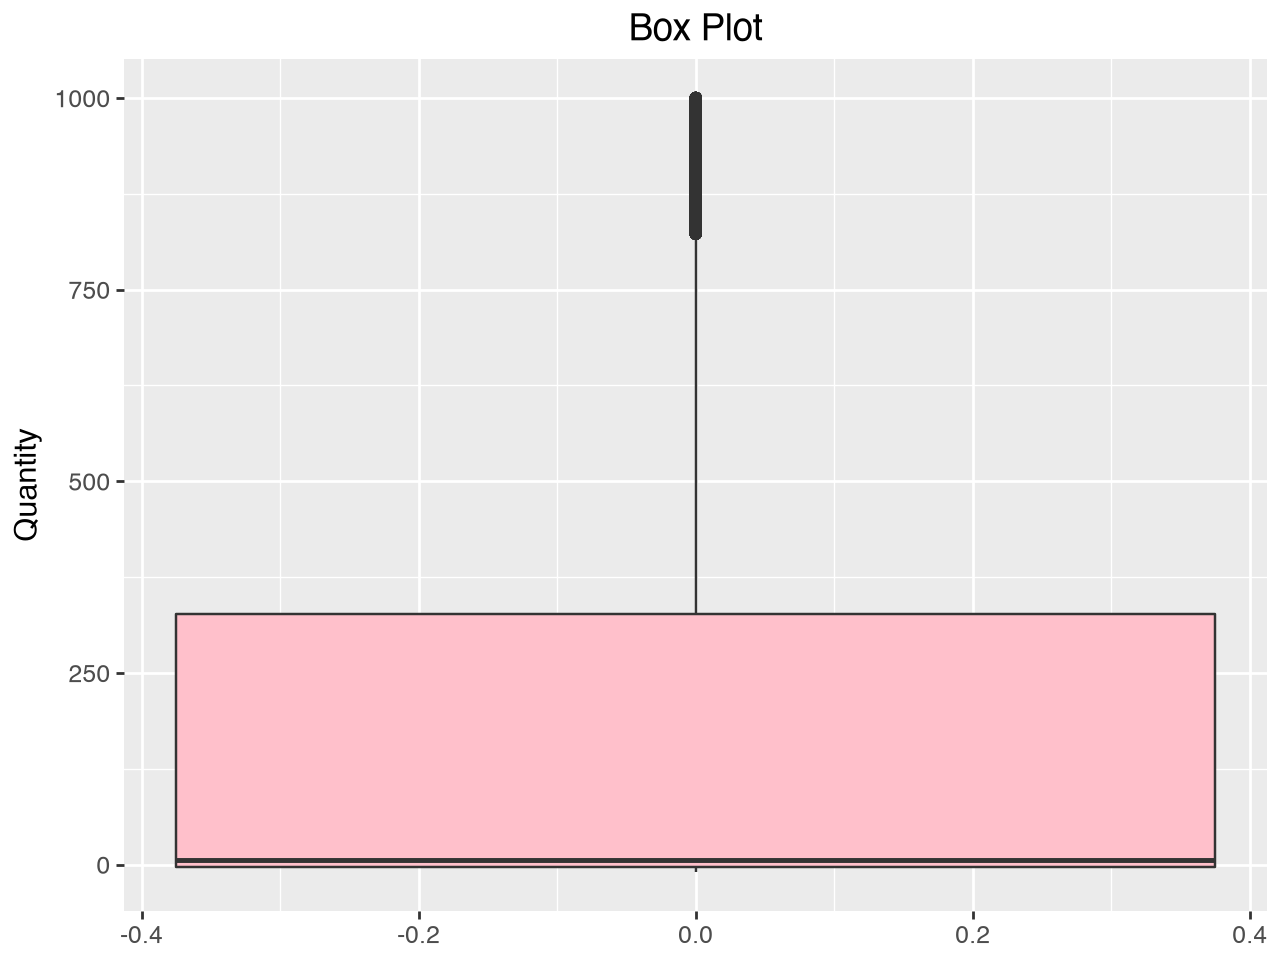

In [64]:
ggplot(df, aes(y=numerical_cols[0])) + \
    geom_boxplot(fill="pink") + \
    labs(
        title="Box Plot",
        y=numerical_cols[0]
    )

/Users/amento/MachineLearning/.venv/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bindot : Removed 27 rows containing non-finite values.


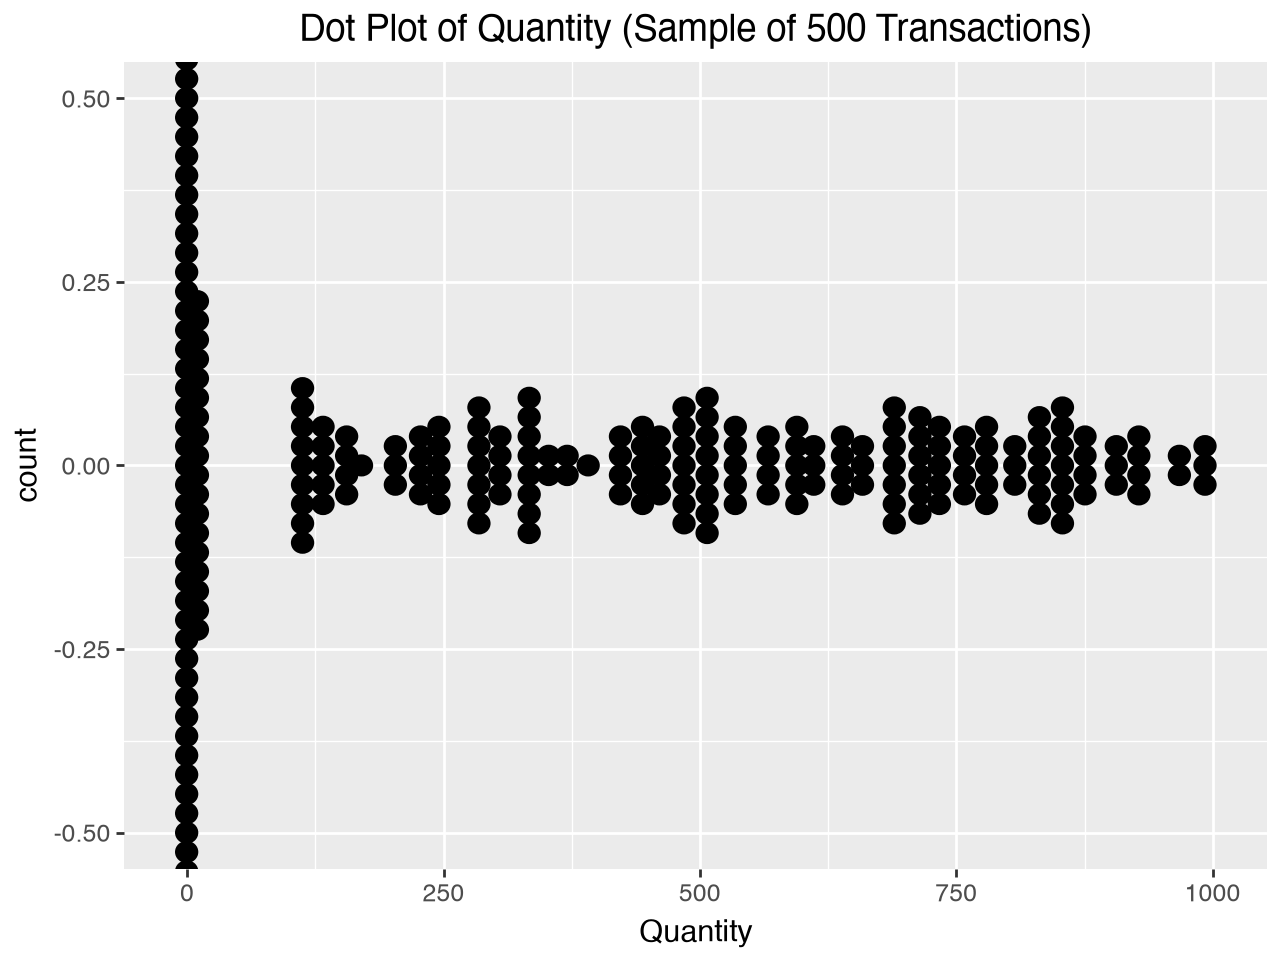

In [65]:
sample_df = df.sample(500, random_state=42)

ggplot(sample_df, aes(x="Quantity")) + \
    geom_dotplot(
        binwidth=20,
        stackdir="center"
    ) + \
    labs(
        title="Dot Plot of Quantity (Sample of 500 Transactions)",
        x="Quantity"
    )

In [66]:
# Import ggplot 

from plotnine import (
    ggplot,
    aes,
    geom_col,
    labs,
    theme_minimal,
    theme,
    element_text,
    coord_flip
)

import pandas as pd

In [67]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include="object").columns

/var/folders/4z/gn6k3wz57v17g3_1zpq2rvzm0000gn/T/ipykernel_2899/603195331.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


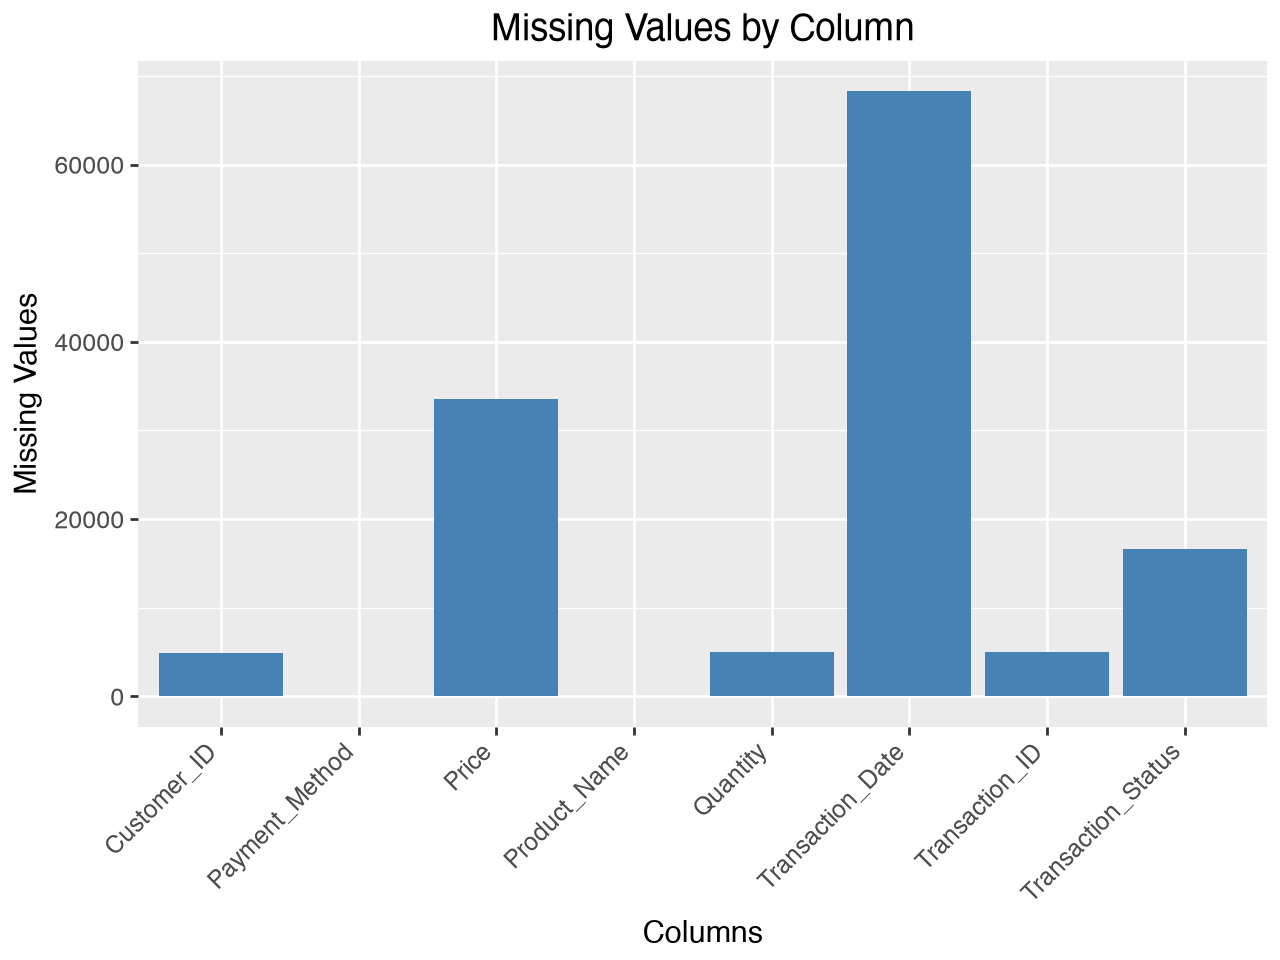

In [68]:
from plotnine import *

missing_data = (
    df.isnull()
      .sum()
      .reset_index()
)

missing_data.columns = ["Column", "Missing_Count"]

(
    ggplot(missing_data,
           aes(x="Column", y="Missing_Count"))
    + geom_col(fill="steelblue")
    + labs(
        title="Missing Values by Column",
        x="Columns",
        y="Missing Values"
    )
    + theme(axis_text_x=element_text(rotation=45, ha="right"))
)

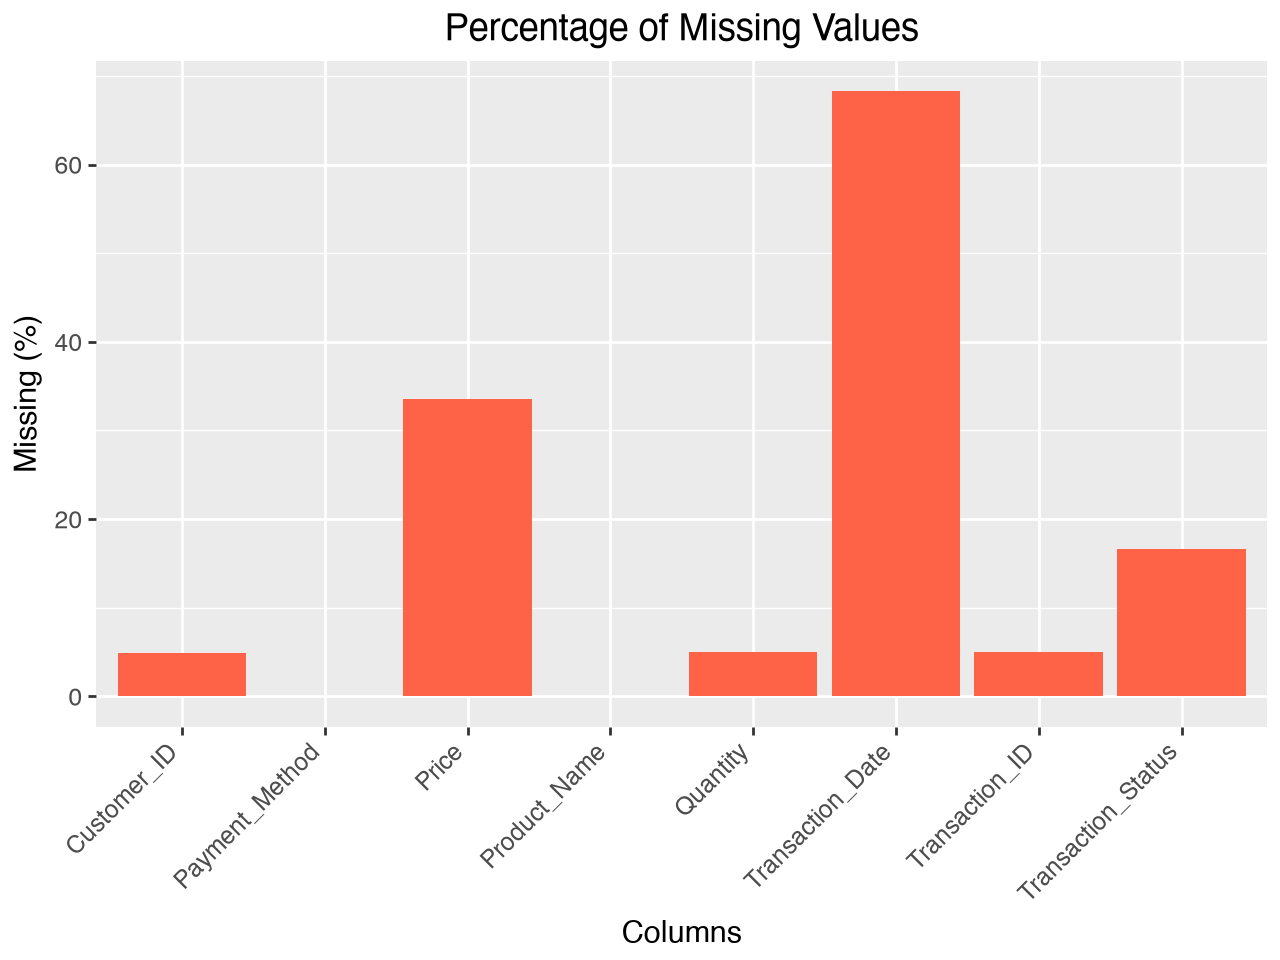

In [69]:
missing_percent = (
    (df.isnull().sum() / len(df)) * 100
).reset_index()

missing_percent.columns = ["Column", "Percentage"]

(
    ggplot(missing_percent,
           aes(x="Column", y="Percentage"))
    + geom_col(fill="tomato")
    + labs(
        title="Percentage of Missing Values",
        x="Columns",
        y="Missing (%)"
    )
    + theme(axis_text_x=element_text(rotation=45, ha="right"))
)

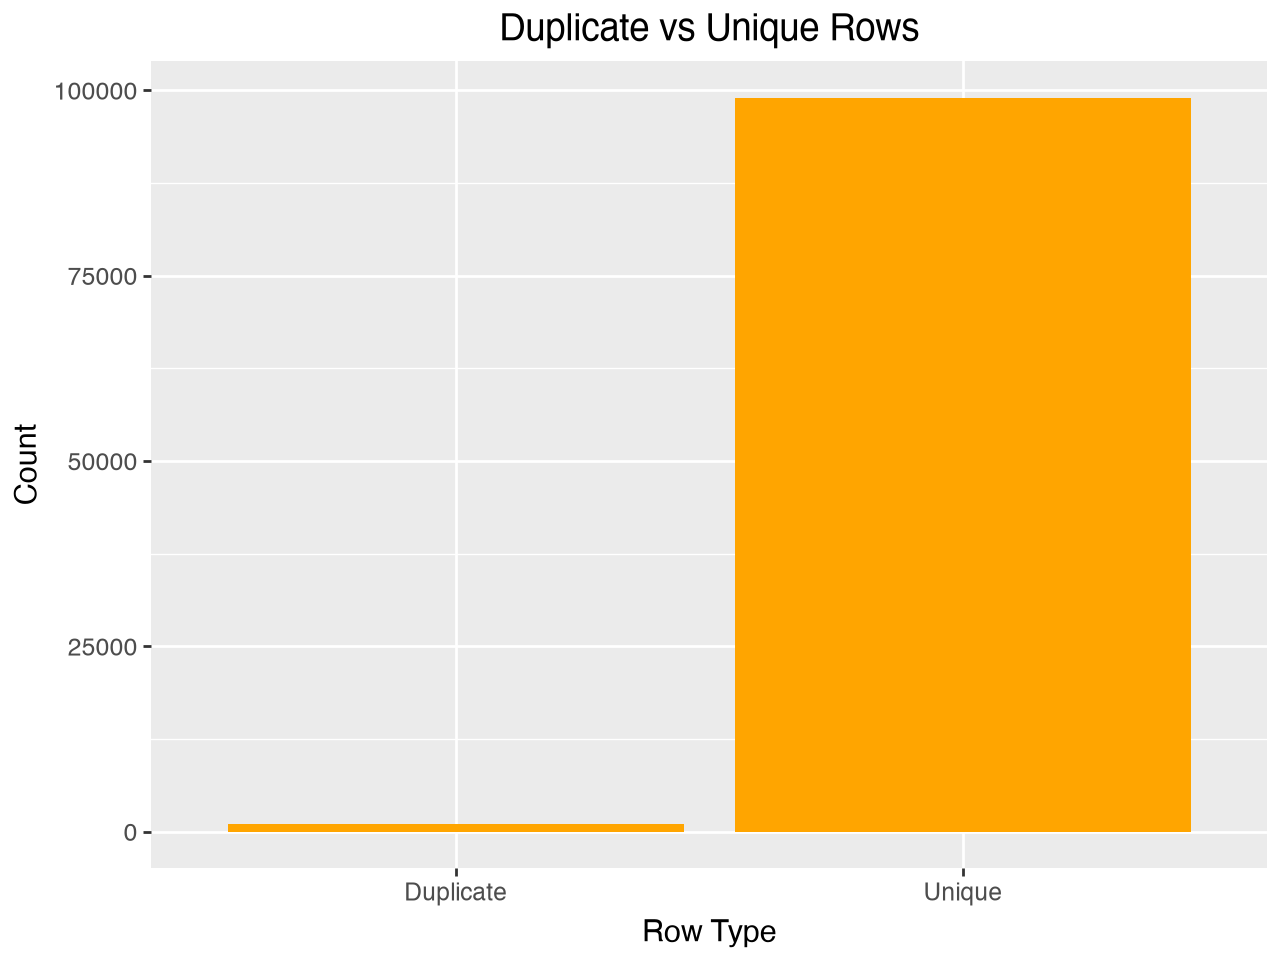

In [70]:
duplicate_data = pd.DataFrame({
    "Type": ["Unique", "Duplicate"],
    "Count": [
        len(df) - df.duplicated().sum(),
        df.duplicated().sum()
    ]
})

(
    ggplot(duplicate_data,
           aes(x="Type", y="Count"))
    + geom_col(fill="orange")
    + labs(
        title="Duplicate vs Unique Rows",
        x="Row Type",
        y="Count"
    )
)

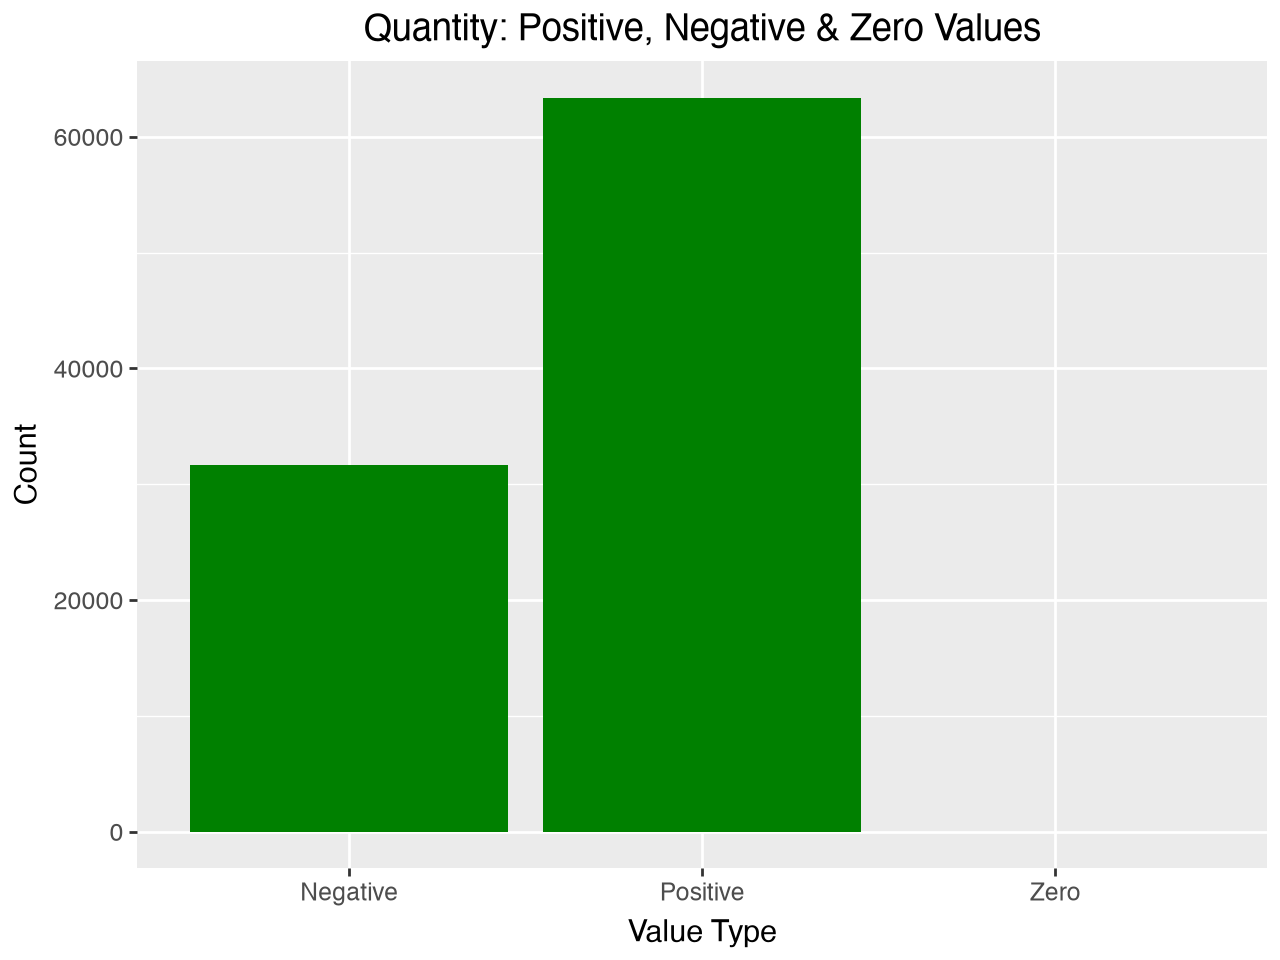

In [71]:
col = "Quantity"

sign_data = pd.DataFrame({
    "Type": ["Positive", "Negative", "Zero"],
    "Count": [
        (df[col] > 0).sum(),
        (df[col] < 0).sum(),
        (df[col] == 0).sum()
    ]
})

(
    ggplot(sign_data,
           aes(x="Type", y="Count"))
    + geom_col(fill="green")
    + labs(
        title=f"{col}: Positive, Negative & Zero Values",
        x="Value Type",
        y="Count"
    )
)

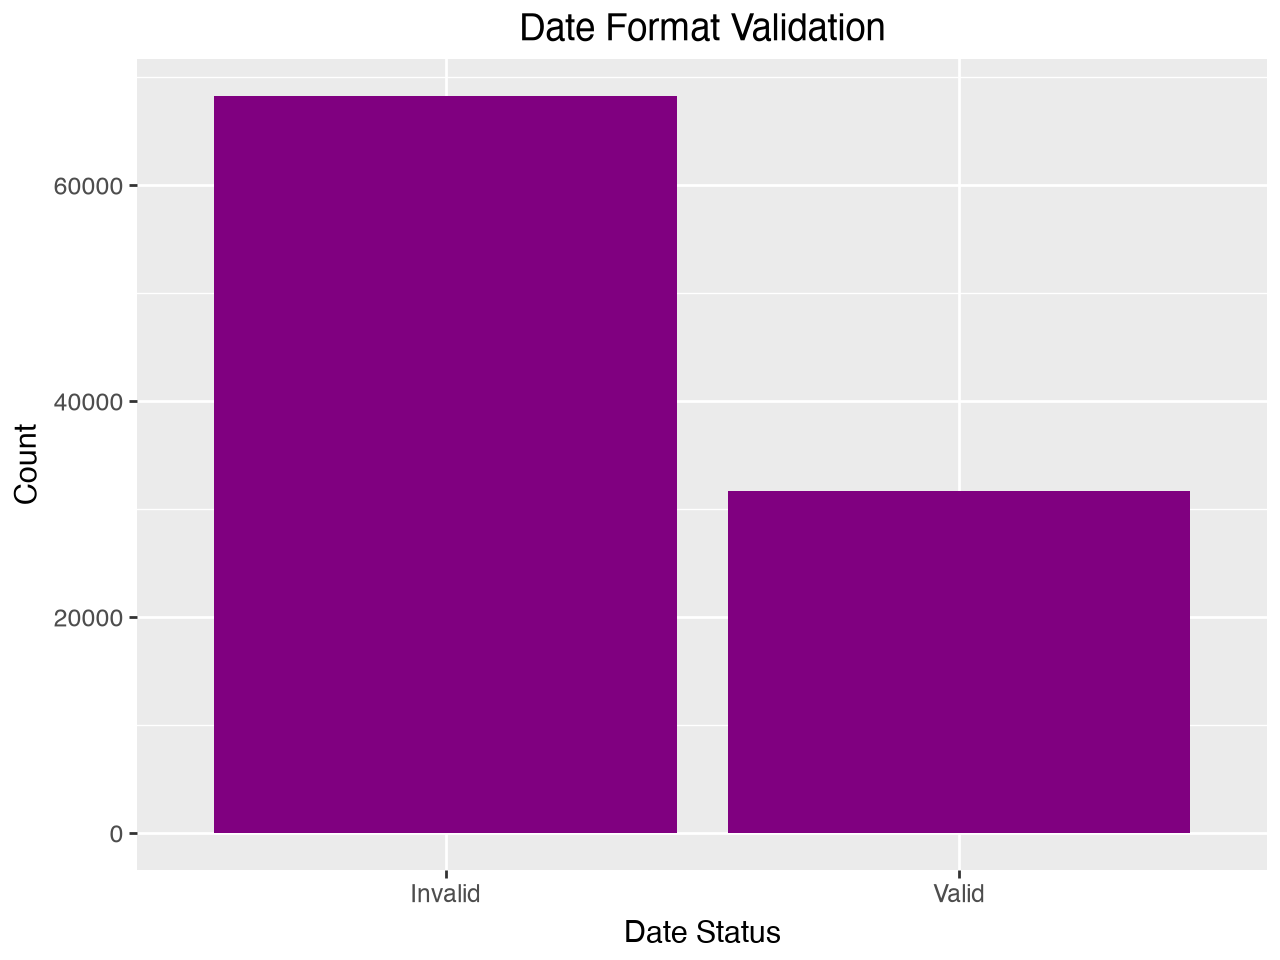

In [72]:
invalid_dates = pd.DataFrame({
    "Status": ["Valid", "Invalid"],
    "Count": [
        df["Transaction_Date"].notna().sum(),
        pd.to_datetime(
            df["Transaction_Date"],
            errors="coerce"
        ).isna().sum()
    ]
})

(
    ggplot(invalid_dates,
           aes(x="Status", y="Count"))
    + geom_col(fill="purple")
    + labs(
        title="Date Format Validation",
        x="Date Status",
        y="Count"
    )
)

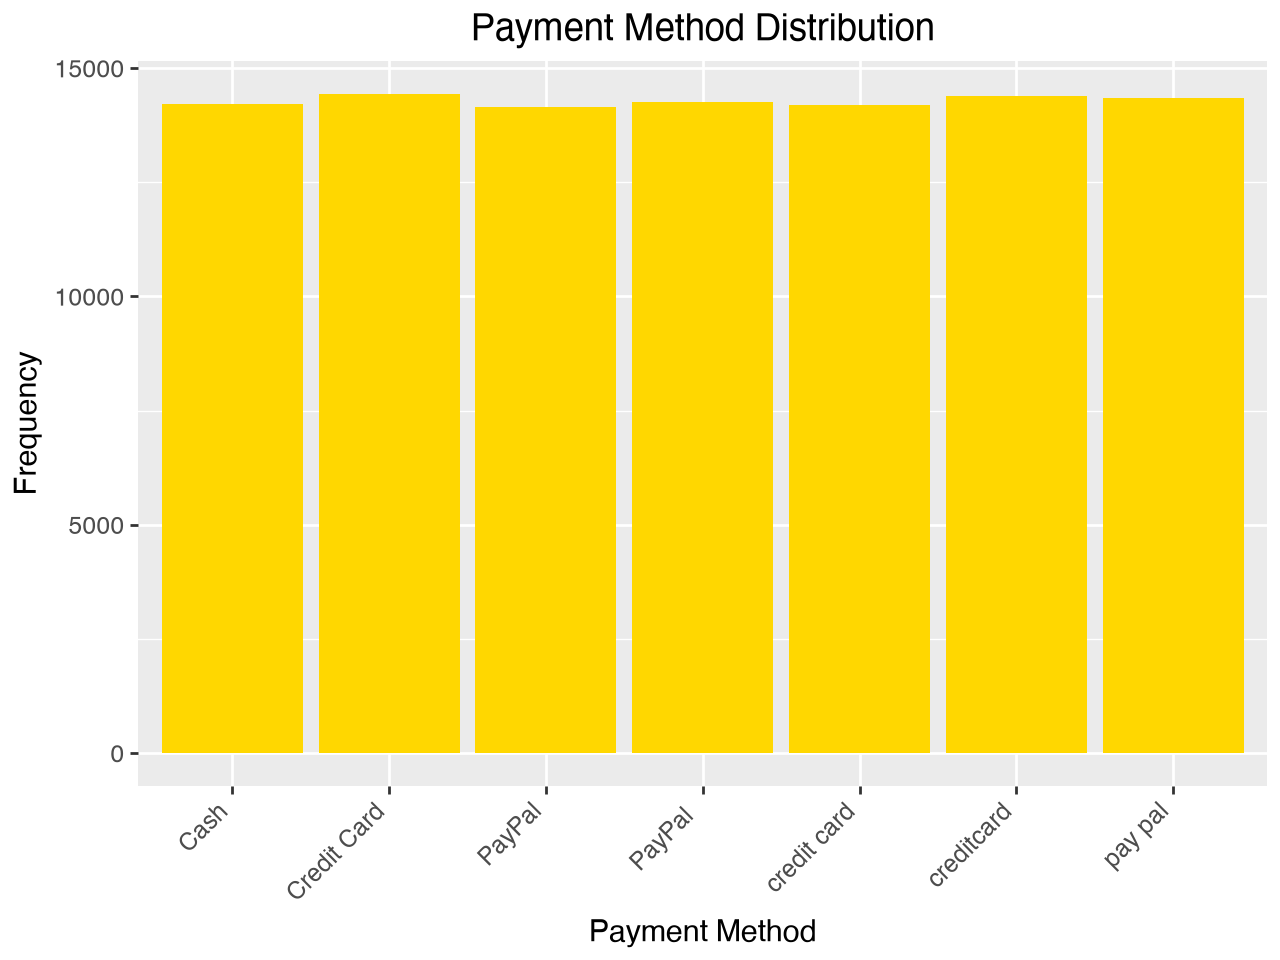

In [73]:
category_data = (
    df["Payment_Method"]
      .value_counts()
      .reset_index()
)

category_data.columns = ["Category", "Count"]

(
    ggplot(category_data,
           aes(x="Category", y="Count"))
    + geom_col(fill="gold")
    + labs(
        title="Payment Method Distribution",
        x="Payment Method",
        y="Frequency"
    )
    + theme(axis_text_x=element_text(rotation=45, ha="right"))
)

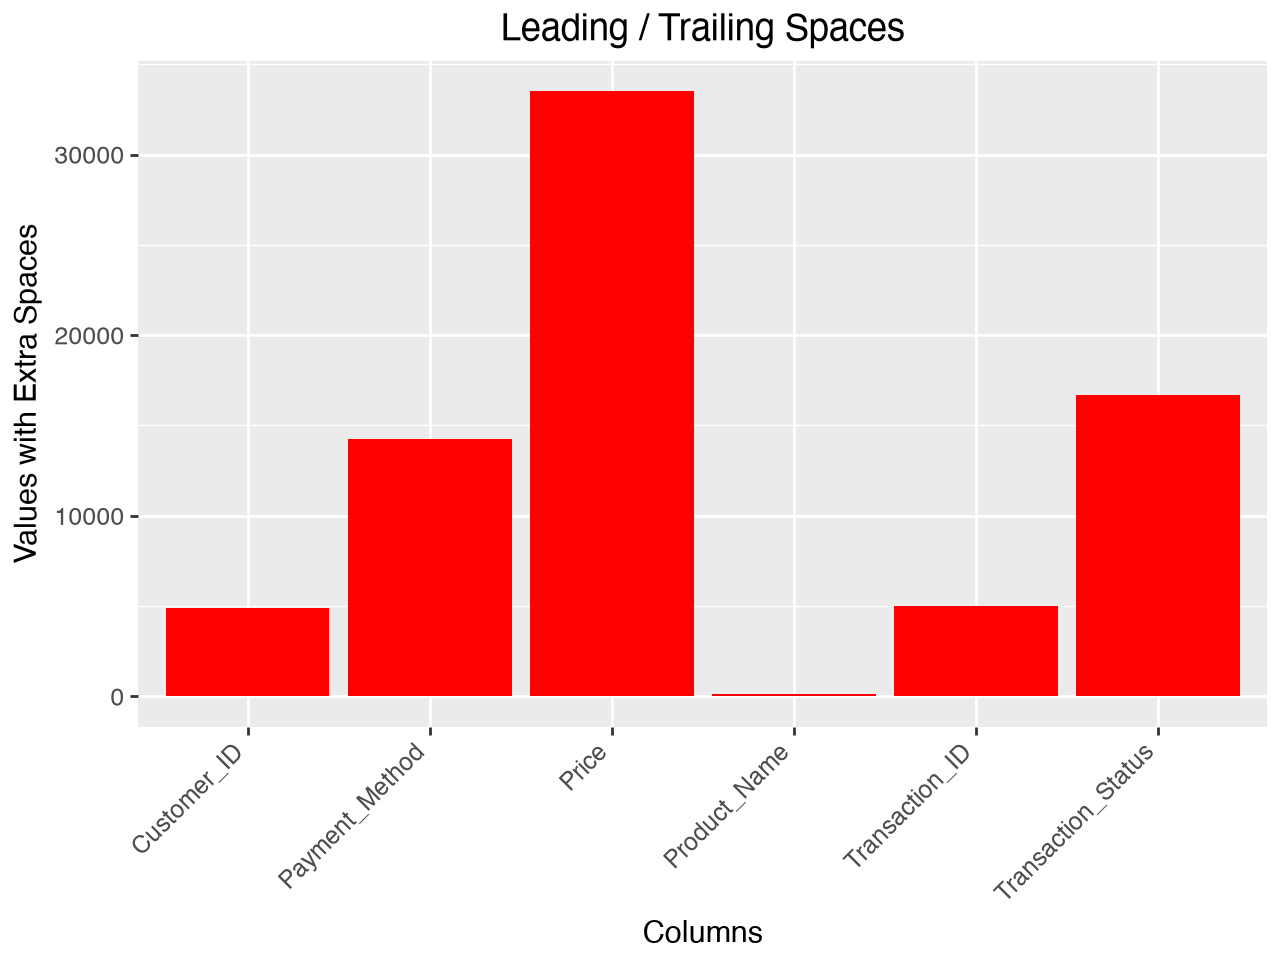

In [74]:
space_counts = []

for col in categorical_cols:
    count = (
        df[col].astype(str).str.strip()
        != df[col].astype(str)
    ).sum()

    space_counts.append([col, count])

space_df = pd.DataFrame(
    space_counts,
    columns=["Column", "Count"]
)

(
    ggplot(space_df,
           aes(x="Column", y="Count"))
    + geom_col(fill="red")
    + labs(
        title="Leading / Trailing Spaces",
        x="Columns",
        y="Values with Extra Spaces"
    )
    + theme(axis_text_x=element_text(rotation=45, ha="right"))
)

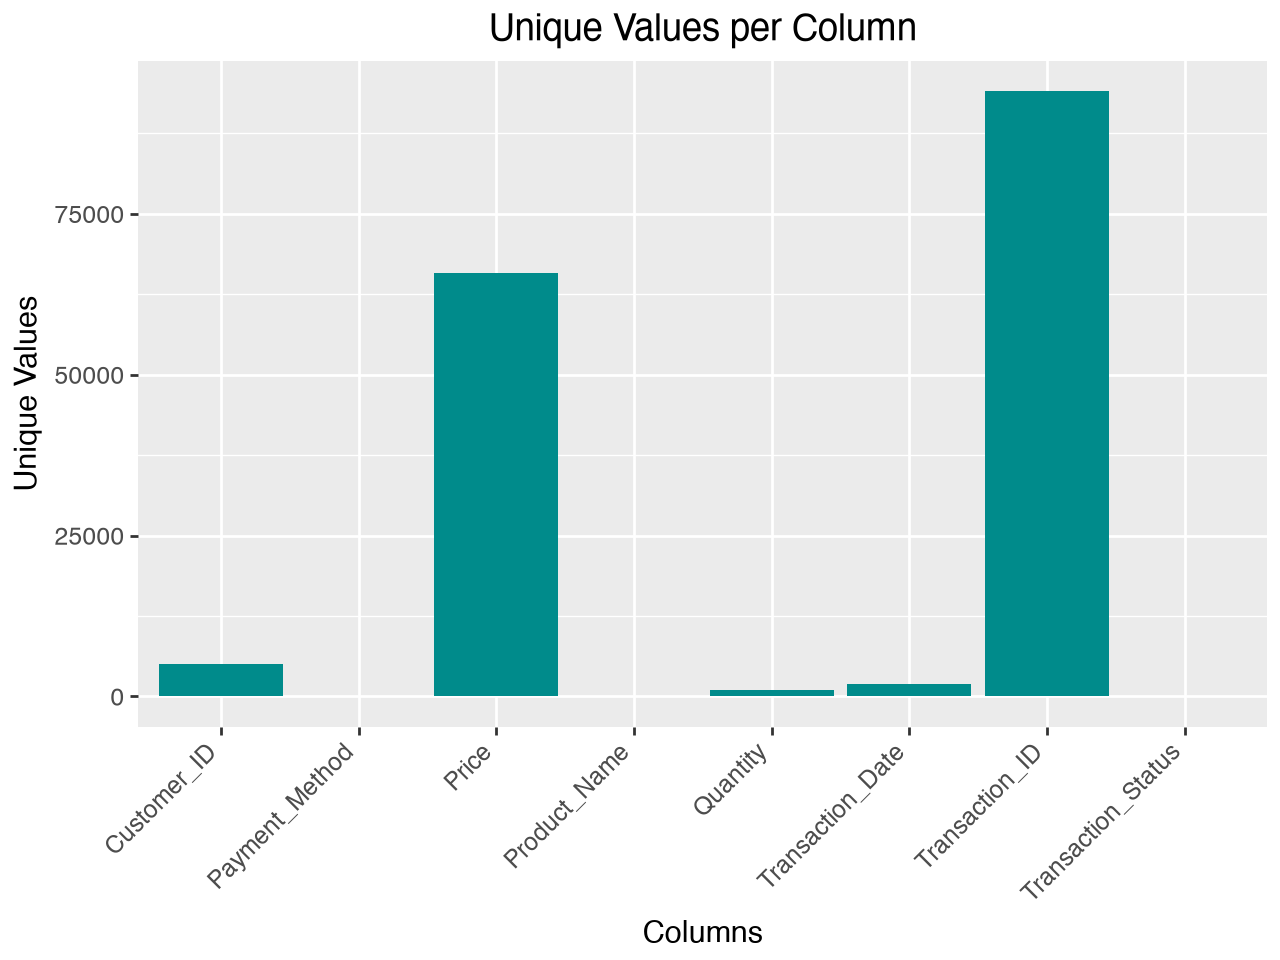

In [77]:
unique_data = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": df.nunique().values
})

(
    ggplot(unique_data,
           aes(x="Column", y="Unique_Values"))
    + geom_col(fill="darkcyan")
    + labs(
        title="Unique Values per Column",
        x="Columns",
        y="Unique Values"
    )
    + theme(axis_text_x=element_text(rotation=45, ha="right"))
)